# Import

In [10]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg
import ast
import colorsys

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
MIX_COLOR = '#C07B7E'
NCR_COLOR = '#FF767C'
NCR_COLOR_DARK = '#FF000B'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [3]:
animals = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']

In [12]:
def bootstrap_dimensionality_all_vars(cov_mats,n_frac=0.5,B=200):
    d_GT_list = []
    d_num_list = []
    d_denom_list = []
    
    for idx_B in range(B):
        n = len(cov_mats)
        sample = np.random.choice(cov_mats,n)\
        
        all_vars = []
        all_covars = []
        for cov in sample:
            if type(cov) is float:
                continue
            cov = np.array(cov)
            if len(cov.shape) < 2:
                continue
            assert cov.shape[0] == cov.shape[1]
            n_clust = cov.shape[0]
            
            new_n = int(n_clust*n_frac)
            if new_n < 1:
                continue
            mask = range(new_n)
            cov= np.array([c[mask] for c in cov[mask]])

            this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
            this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
            all_vars.append(this_vars)
            all_covars.append(this_covars)
        all_vars = np.concatenate(all_vars)
        all_covars = np.concatenate(all_covars)

        n = len(all_vars)
        avg_sq_vars = np.nanmean(all_vars**2)
        avg_sq_covars = np.nanmean(all_covars**2)
        avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])
        d_GT = avg_pred_covars/avg_sq_covars
        d_GT_list.append(d_GT)
        d_num_list.append(avg_pred_covars)
        d_denom_list.append(avg_sq_covars)
        
    d_GT_list = ilep.rmnan(d_GT_list)
    d_GT_estimate = np.mean(d_GT_list)
    SEM_d_GT_estimate = sem(d_GT_list)

    all_vars = []
    all_covars = []
    for cov in cov_mats:
        if type(cov) is float:
            continue
        cov = np.array(cov)
        if len(cov.shape) < 2:
            continue
        assert cov.shape[0] == cov.shape[1]
        n_clust = cov.shape[0]

        new_n = int(n_clust*n_frac)
        if new_n < 1:
            continue
        mask = range(new_n)
        cov= np.array([c[mask] for c in cov[mask]])

        this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
        this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
        all_vars.append(this_vars)
        all_covars.append(this_covars)
    all_vars = np.concatenate(all_vars)
    all_covars = np.concatenate(all_covars)
        
    all_vars = ilep.rmnan(all_vars)
    all_covars = ilep.rmnan(np.abs(all_covars)) #abs because only the squared value matters for the calculation
        
    return d_GT_estimate,SEM_d_GT_estimate,  np.mean(all_vars),sem(all_vars),   np.mean(all_covars),sem(all_covars)

In [13]:
def bootstrap_dimensionality_all_vars_median_IQR(cov_mats,n_frac=0.5,B=200):
    d_GT_list = []
    d_num_list = []
    d_denom_list = []
    
    for idx_B in range(B):
        n = len(cov_mats)
        sample = np.random.choice(cov_mats,n)
#         sample = cov_mats
        
        all_vars = []
        all_covars = []
        for cov in sample:
            if type(cov) is float:
                continue
            cov = np.array(cov)
            if len(cov.shape) < 2:
                continue
            assert cov.shape[0] == cov.shape[1]
            n_clust = cov.shape[0]
            
            new_n = int(n_clust*n_frac)
            if new_n < 1:
                continue
            mask = range(new_n)
            cov= np.array([c[mask] for c in cov[mask]])

            this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
            this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
            all_vars.append(this_vars)
            all_covars.append(this_covars)
        all_vars = np.concatenate(all_vars)
        all_covars = np.concatenate(all_covars)

        n = len(all_vars)
        avg_sq_vars = np.nanmean(all_vars**2)
        avg_sq_covars = np.nanmean(all_covars**2)
        avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])
        
#         d_GT = calc_dim(n,avg_pred_covars/avg_sq_vars,avg_sq_covars/avg_sq_vars)
        d_GT = avg_pred_covars/avg_sq_covars
        d_GT_list.append(d_GT)
        d_num_list.append(avg_pred_covars)
        d_denom_list.append(avg_sq_covars)
        
    d_GT_list = ilep.rmnan(d_GT_list)
    d_GT_estimate = np.median(d_GT_list)
    d_GT_Q1_estimate = np.percentile(d_GT_list,25)
    d_GT_Q3_estimate = np.percentile(d_GT_list,75)
    SEM_d_GT_estimate = sem(d_GT_list)# / np.sqrt(B)

    all_vars = []
    all_covars = []
    for cov in cov_mats:
        if type(cov) is float:
            continue
        cov = np.array(cov)
        if len(cov.shape) < 2:
            continue
        assert cov.shape[0] == cov.shape[1]
        n_clust = cov.shape[0]

        new_n = int(n_clust*n_frac)
        if new_n < 1:
            continue
        mask = range(new_n)
        cov= np.array([c[mask] for c in cov[mask]])

        this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
        this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
        all_vars.append(this_vars)
        all_covars.append(this_covars)
    all_vars = np.concatenate(all_vars)
    all_covars = np.concatenate(all_covars)
        
    all_vars = ilep.rmnan(all_vars)
    all_covars = ilep.rmnan(np.abs(all_covars)) #abs because only the squared value matters for the calculation
    
#     print(f"{np.mean(d_GT_estimate)} +/- {np.std(d_GT_estimate)}")
#     print(f"{d_GT_Q1_estimate} +/- {d_GT_Q3_estimate}")
        
    return d_GT_estimate,d_GT_Q1_estimate,d_GT_Q3_estimate,  np.median(all_vars),np.percentile(all_vars,25),np.percentile(all_vars,75),   np.median(all_covars),np.percentile(all_covars,25),np.percentile(all_covars,75)

In [14]:
with open('../../Source Data Files/Cov_Mats_Clustered.pickle', 'rb') as f:
    Data = pickle.load(f)

Data.sessions = np.array(Data.sessions,dtype=str)
Data.phases = np.array(Data.phases,dtype=str)
Data.cov_mats = np.array(Data.cov_mats,dtype='object')
Data.cov_mats_CR = np.array(Data.cov_mats_CR,dtype='object')
Data.cov_mats_NCR = np.array(Data.cov_mats_NCR,dtype='object')
Data.cov_mats_CRNCR = np.array(Data.cov_mats_CRNCR,dtype='object')

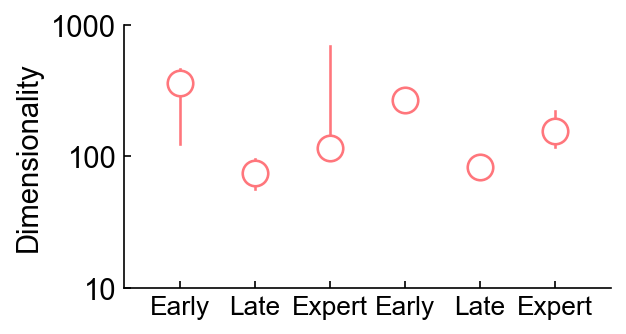

In [15]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

def statsbar(ax,barheight,xpoints,stemheights,text=None,lw=1):
    ymax = ax.get_ylim()[1]
    ymin = ax.get_ylim()[0]
    yrange = ymax-ymin
    ydist = 0.025*yrange
    
    ax.plot([xpoints[0]]*2,[stemheights[0]+ydist,barheight],lw=lw,color='k')
    ax.plot([xpoints[1]]*2,[stemheights[1]+ydist,barheight],lw=lw,color='k')
    ax.plot(xpoints,[barheight]*2,lw=lw,color='k')
    
    if not text is None:
        ax.text(np.mean(xpoints),barheight + ydist,text,horizontalalignment='center',verticalalignment='center')
        
fig,ax = make_axis_size(3.25, 1.75, left=.3, bottom=.3, right=0, top=0)
sz=150
s_wid=1.25
offset=0#.175
switch_offset=0
        
phases = ['pre early','pre late','pre expert','post early','post late','post expert']
for idx,phase in enumerate(phases):
    phase_mask = np.char.equal(Data.phases,phase)
    
    cov_mats = np.array(Data.cov_mats_NCR,dtype='object')[phase_mask]
    M,Q1,Q3,Mnum,Q1num,Q3num,Mden,Q1den,Q3den = bootstrap_dimensionality_all_vars_median_IQR(cov_mats,n_frac = 1,B=2000)
    
    ax.scatter(idx-offset,np.log10(M),ec=NCR_COLOR,fc='white',s=sz,lw=s_wid,zorder=10)
    ax.plot([idx-offset,idx-offset],[np.log10(Q1),np.log10(Q3)],c=NCR_COLOR,lw=s_wid)

ax.set_ylim([1,3])
ax.set_yticks([1,2,3])
ax.set_yticklabels(['10','100','1000'])
ax.set_ylabel('Dimensionality')
    
labels = ['Early','Late','Expert','Early','Late','Expert']
ax.set_xlim([-0.75-switch_offset,5.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)
    
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
    
artists = []
# fig.savefig(os.path.join('..','..','Figures','Figure 4b top.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

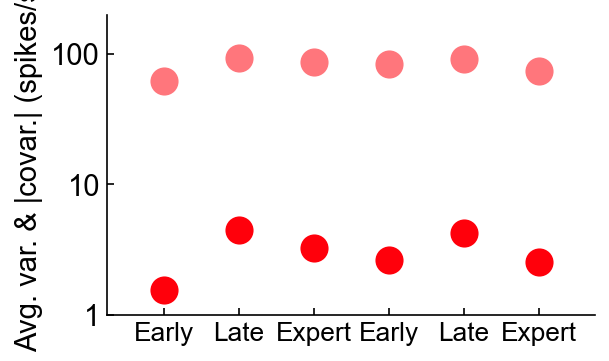

In [16]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

def statsbar(ax,barheight,xpoints,stemheights,text=None,lw=1):
    ymax = ax.get_ylim()[1]
    ymin = ax.get_ylim()[0]
    yrange = ymax-ymin
    ydist = 0.025*yrange
    
    ax.plot([xpoints[0]]*2,[stemheights[0]+ydist,barheight],lw=lw,color='k')
    ax.plot([xpoints[1]]*2,[stemheights[1]+ydist,barheight],lw=lw,color='k')
    ax.plot(xpoints,[barheight]*2,lw=lw,color='k')
    
    if not text is None:
        ax.text(np.mean(xpoints),barheight + ydist,text,horizontalalignment='center',verticalalignment='center')
        
fig,ax = make_axis_size(3.25, 2, left=.3, bottom=.3, right=0, top=0)
sz=150
s_wid=1.25
offset=0#.175
switch_offset=0
        
phases = ['pre early','pre late','pre expert','post early','post late','post expert']
for idx,phase in enumerate(phases):
    phase_mask = np.char.equal(Data.phases,phase)
    
    cov_mats = np.array(Data.cov_mats_NCR,dtype='object')[phase_mask]
    M,SEM,Mnum,SEMnum,Mden,SEMden = bootstrap_dimensionality_all_vars(cov_mats,n_frac = 1,B=2000)
    
    ax.scatter(idx-0*offset,np.log10(Mnum),c=NCR_COLOR,s=sz,lw=s_wid,zorder=10)
    ax.plot([idx-0*offset,idx-0*offset],[np.log10(Mnum-SEMnum),np.log10(Mnum+SEMnum)],c='gray',lw=s_wid)
    
    ax.scatter(idx+offset,np.log10(Mden),c=NCR_COLOR_DARK,s=sz,lw=s_wid,zorder=10)
    ax.plot([idx+offset,idx+offset],[np.log10(Mden-SEMden),np.log10(Mden+SEMden)],c='gray',lw=s_wid)

ax.set_ylim([0,np.log10(200)])
ax.set_yticks([0,1,2])
ax.set_yticklabels(['1','10','100'])
ax.set_ylabel('Avg. var. & |covar.| (spikes/s)')
    
labels = ['Early','Late','Expert','Early','Late','Expert']
ax.set_xlim([-0.75-switch_offset,5.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)
    
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
    
artists = []
# fig.savefig(os.path.join('..','..','Figures','Figure 4b bottom.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [26]:
def bootstrap_dimm_stats(cov_mats_1,cov_mats_2,B=250000,n_frac=1):
    
    d_GT_list_1 = []
    d_num_list_1 = []
    d_den_list_1 = []
    for idx_B in range(B):
        try:
            n = len(cov_mats_1)
            sample = np.random.choice(cov_mats_1,n)

            all_vars = []
            all_covars = []
            for cov in sample:
                if type(cov) is float:
                    continue
                cov = np.array(cov)
                if len(cov.shape) < 2:
                    continue
                assert cov.shape[0] == cov.shape[1]
                n_clust = cov.shape[0]

                new_n = int(n_clust*n_frac)
                if new_n < 1:
                    continue
                mask = range(new_n)
                cov= np.array([c[mask] for c in cov[mask]])

                this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
                this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
                all_vars.append(this_vars)
                all_covars.append(this_covars)
            all_vars = np.concatenate(all_vars)
            all_covars = np.concatenate(all_covars)
            
            n = len(all_vars)
            avg_sq_vars = np.nanmean(all_vars**2)
            avg_sq_covars = np.nanmean(all_covars**2)
            avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])
            
            d_GT = avg_pred_covars/avg_sq_covars
            d_GT_list_1.append(d_GT)
            d_num_list_1.append(avg_pred_covars)
            d_den_list_1.append(avg_sq_covars)
        except Exception as e:
            print(f"L: {e}")
            d_GT_list_1.append(np.nan)
            d_num_list_1.append(np.nan)
            d_den_list_1.append(np.nan)
    
    d_GT_list_2 = []
    d_num_list_2 = []
    d_den_list_2 = []
    for idx_B in range(B):
        try:
            n = len(cov_mats_2)
            sample = np.random.choice(cov_mats_2,n)

            all_vars = []
            all_covars = []
            for cov in sample:
                if type(cov) is float:
                    continue
                cov = np.array(cov)
                if len(cov.shape) < 2:
                    continue
                assert cov.shape[0] == cov.shape[1]
                n_clust = cov.shape[0]

                new_n = int(n_clust*n_frac)
                if new_n < 1:
                    continue
                mask = range(new_n)
                cov= np.array([c[mask] for c in cov[mask]])

                this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
                this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
                all_vars.append(this_vars)
                all_covars.append(this_covars)
            all_vars = np.concatenate(all_vars)
            all_covars = np.concatenate(all_covars)

            n = len(all_vars)
            avg_sq_vars = np.nanmean(all_vars**2)
            avg_sq_covars = np.nanmean(all_covars**2)
            avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])

            d_GT = avg_pred_covars/avg_sq_covars
            d_GT_list_2.append(d_GT)
            d_num_list_2.append(avg_pred_covars)
            d_den_list_2.append(avg_sq_covars)
        except:
            d_GT_list_2.append(np.nan)
            d_num_list_2.append(np.nan)
            d_den_list_2.append(np.nan)
        
        
        
    #Two-sided test
    X,Y = ilep.paired_rmnan(d_GT_list_1,d_GT_list_2)
    diffs = (np.array(X) - np.array(Y))
    pY = 1 - np.mean(np.greater(diffs,0))
    pX = 1 - np.mean(np.less(diffs,0))
    pboot1 = min(pX,pY)*2
    
    X,Y = ilep.paired_rmnan(d_num_list_1,d_num_list_2)
    diffs = (np.array(X) - np.array(Y))
    pY = 1 - np.mean(np.greater(diffs,0))
    pX = 1 - np.mean(np.less(diffs,0))
    pboot2 = min(pX,pY)*2
    
    X,Y = ilep.paired_rmnan(d_den_list_1,d_den_list_2)
    diffs = (np.array(X) - np.array(Y))
    pY = 1 - np.mean(np.greater(diffs,0))
    pX = 1 - np.mean(np.less(diffs,0))
    pboot3 = min(pX,pY)*2
    return pboot1,pboot2,pboot3

In [28]:
def trad_stats_num_den(cov_mats_1,cov_mats_2):
    
    all_vars1 = []
    all_covars1 = []
    for cov in cov_mats_1:
        if type(cov) is float:
            continue
        cov = np.array(cov)
        if len(cov.shape) < 2:
            continue
        assert cov.shape[0] == cov.shape[1]
        n_clust = cov.shape[0]

        this_vars1 = cov[np.eye(n_clust,n_clust,dtype='bool')]
        this_covars1 = cov[~np.eye(n_clust,n_clust,dtype='bool')]
        all_vars1.append(this_vars1)
        all_covars1.append(this_covars1)
    all_vars1 = np.concatenate(all_vars1)
    all_covars1 = np.abs(np.concatenate(all_covars1))
#     n = len(all_vars1)
#     sq_covars1 = (all_covars1**2)
#     pred_covars1 = (np.outer(all_vars1,all_vars1)[~np.eye(n,n,dtype='bool')])
    
    all_vars2 = []
    all_covars2 = []
    for cov in cov_mats_2:
        if type(cov) is float:
            continue
        cov = np.array(cov)
        if len(cov.shape) < 2:
            continue
        assert cov.shape[0] == cov.shape[1]
        n_clust = cov.shape[0]

        this_vars2 = cov[np.eye(n_clust,n_clust,dtype='bool')]
        this_covars2 = cov[~np.eye(n_clust,n_clust,dtype='bool')]
        all_vars2.append(this_vars2)
        all_covars2.append(this_covars2)
    all_vars2 = np.concatenate(all_vars2)
    all_covars2 = np.abs(np.concatenate(all_covars2))
    
    _,p1 = ttest_ind(ilep.rmnan(all_vars1),ilep.rmnan(all_vars2))
    _,p2 = ttest_ind(ilep.rmnan(all_covars1),ilep.rmnan(all_covars2))
    return p1,p2

In [36]:
phases = ['pre early','pre late','pre expert','post early','post late','post expert']
B = 2500
    
phase_mask1 = np.char.equal(Data.phases,'pre early')
phase_mask2 = np.char.equal(Data.phases,'pre late')
cov1 = np.array(Data.cov_mats_NCR[phase_mask1])
cov2 = np.array(Data.cov_mats_NCR[phase_mask2])
p1,pp1 = trad_stats_num_den(cov1,cov2)
ppp1 = bootstrap_dimm_stats(cov1,cov2,B=B)

phase_mask1 = np.char.equal(Data.phases,'pre late')
phase_mask2 = np.char.equal(Data.phases,'pre expert')
cov1 = np.array(Data.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data.cov_mats_NCR)[phase_mask2]
p2,pp2 = trad_stats_num_den(cov1,cov2)
ppp2 = bootstrap_dimm_stats(cov1,cov2,B=B)

phase_mask1 = np.char.equal(Data.phases,'pre early')
phase_mask2 = np.char.equal(Data.phases,'pre expert')
cov1 = np.array(Data.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data.cov_mats_NCR)[phase_mask2]
p3,pp3 = trad_stats_num_den(cov1,cov2)
ppp3 = bootstrap_dimm_stats(cov1,cov2,B=B)


phase_mask1 = np.char.equal(Data.phases,'post early')
phase_mask2 = np.char.equal(Data.phases,'post late')
cov1 = np.array(Data.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data.cov_mats_NCR)[phase_mask2]
p4,pp4 = trad_stats_num_den(cov1,cov2)
ppp4 = bootstrap_dimm_stats(cov1,cov2,B=B)

phase_mask1 = np.char.equal(Data.phases,'post late')
phase_mask2 = np.char.equal(Data.phases,'post expert')
cov1 = np.array(Data.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data.cov_mats_NCR)[phase_mask2]
p5,pp5 = trad_stats_num_den(cov1,cov2)
ppp5 = bootstrap_dimm_stats(cov1,cov2,B=B)

phase_mask1 = np.char.equal(Data.phases,'post early')
phase_mask2 = np.char.equal(Data.phases,'post expert')
cov1 = np.array(Data.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data.cov_mats_NCR)[phase_mask2]
p6,pp6 = trad_stats_num_den(cov1,cov2)
ppp6 = bootstrap_dimm_stats(cov1,cov2,B=B)

pvals = [p1,p2,p3,p4,p5,p6]
_,p_corr = pg.multicomp(pvals,method='fdr_bh')
print('Numerator')
print(p_corr)

ppvals = [pp1,pp2,pp3,pp4,pp5,pp6]
_,pp_corr = pg.multicomp(ppvals,method='fdr_bh')
print('Denominator')
print(pp_corr)

pppvals = [ppp1,ppp2,ppp3,ppp4,ppp5,ppp6]
_,ppp_corr = pg.multicomp(pppvals,method='fdr_bh')
print('Dim')
print(ppp_corr)

Numerator
[0.10192216 0.7677971  0.10192216 0.36476261 0.16590088 0.33950765]
Denominator
[3.41533670e-31 1.00077391e-01 1.05895971e-09 3.77095400e-23
 1.43315067e-09 5.60409227e-01]
Dim
[[0.3168     0.1836     0.1488    ]
 [0.4256     0.69035294 0.4692    ]
 [0.824      0.3294     0.63648   ]
 [0.1488     0.51737143 0.1488    ]
 [0.42912    0.3294     0.3294    ]
 [0.4692     0.51737143 0.69035294]]
